In [1]:
from utils_ml import *

In [2]:
old_label_arr = np.array([np.tile(i, 3000) for i in np.arange(0,8)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

new_label_arr = convert_labels(old_label_arr, class_to_poles)

In [3]:
features_regression = np.load('data/features_selected.npy', mmap_mode='r+')
X_train, X_test, y_train, y_test = train_test_split(features_regression, new_label_arr,random_state=42, test_size=0.1)

In [4]:
kfold = KFold(n_splits=2, shuffle=True, random_state=42)
kfold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
    
    # rg = CatBoostRegressor(
    #   verbose=100,           
    #   random_state=fold,
    #   loss_function="MultiRMSE",
    #   depth=7
    #   )

    rg = CatBoostRegressor(
        loss_function="MultiRMSE",
        iterations=2000,             
      depth=9,                     
      learning_rate=0.03,          
      subsample=0.8,               
      bootstrap_type='Bernoulli',
      random_seed=fold,
      verbose=100,
      l2_leaf_reg=10,              
      early_stopping_rounds=200  
      )
    
    rg.fit(X_train[train_idx], y_train[train_idx], eval_set=(X_train[val_idx],y_train[val_idx]), plot=False)
    kfold_models.append(rg)
    rg.save_model(f"saved_models/model_fold_rg_multirmse_8_{fold}")

0:	learn: 0.9964631	test: 0.9983871	best: 0.9983871 (0)	total: 884ms	remaining: 29m 26s
100:	learn: 0.4519200	test: 0.4710147	best: 0.4710147 (100)	total: 1m 24s	remaining: 26m 37s
200:	learn: 0.3895453	test: 0.4258747	best: 0.4258747 (200)	total: 2m 47s	remaining: 25m 1s
300:	learn: 0.3556049	test: 0.4065685	best: 0.4065685 (300)	total: 4m 10s	remaining: 23m 31s
400:	learn: 0.3218940	test: 0.3884596	best: 0.3884596 (400)	total: 5m 33s	remaining: 22m 8s
500:	learn: 0.2985252	test: 0.3780489	best: 0.3780489 (500)	total: 6m 52s	remaining: 20m 32s
600:	learn: 0.2799693	test: 0.3706423	best: 0.3706423 (600)	total: 8m 10s	remaining: 19m 2s
700:	learn: 0.2652455	test: 0.3654392	best: 0.3654392 (700)	total: 9m 29s	remaining: 17m 35s
800:	learn: 0.2516467	test: 0.3615542	best: 0.3615542 (800)	total: 10m 48s	remaining: 16m 10s
900:	learn: 0.2386048	test: 0.3577998	best: 0.3577998 (900)	total: 12m 7s	remaining: 14m 46s
1000:	learn: 0.2270976	test: 0.3548275	best: 0.3548275 (1000)	total: 13m 25s	

In [5]:
acc_arr = []
for cnt, submodel in enumerate(kfold_models):
    
    _pred = submodel.predict(X_test)
    acc_arr.extend([np.sum(np.sum(np.round(_pred)==y_test,axis=1) == 3)/np.sum(np.ones_like(y_test[:,0]))])
print(f"Test Accuracy = {np.mean(acc_arr):.4f} +/- {np.std(acc_arr):.3f}")

Test Accuracy = 0.8881 +/- 0.002


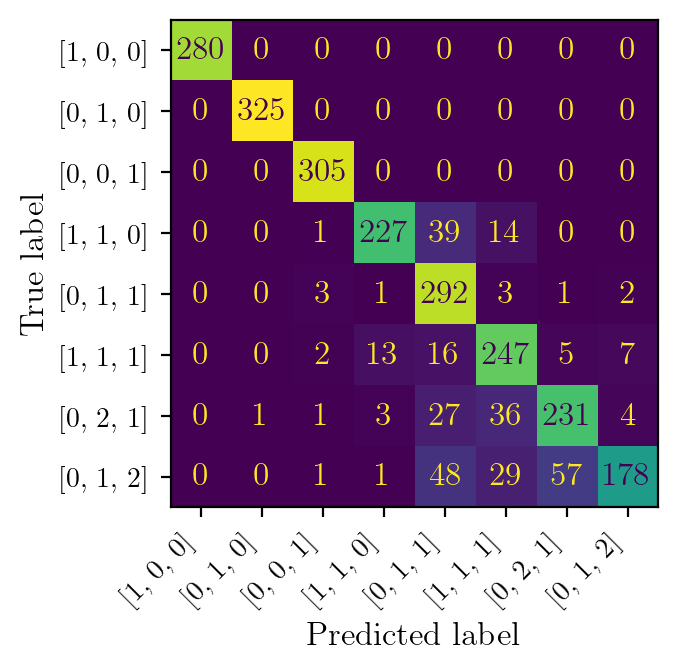

In [6]:
# Custom class-to-poles mapping
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

# Custom labels for the axes
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Aggregate predictions over the folds
mean_predictions = [] #np.zeros((len(X_test), len(class_to_poles)))
for model in kfold_models:
    _preds = model.predict(X_test)
    predictions = reconvert_labels(np.abs(np.round(_preds)).tolist(), class_to_poles)
    mean_predictions.append(predictions)

mean_predictions = np.round(np.array(mean_predictions).mean(axis=0))
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), mean_predictions, labels=np.arange(len(class_to_poles)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(3.54331, 3.54331))  # Adjust figure size if needed
disp.plot(ax=ax,colorbar=False)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

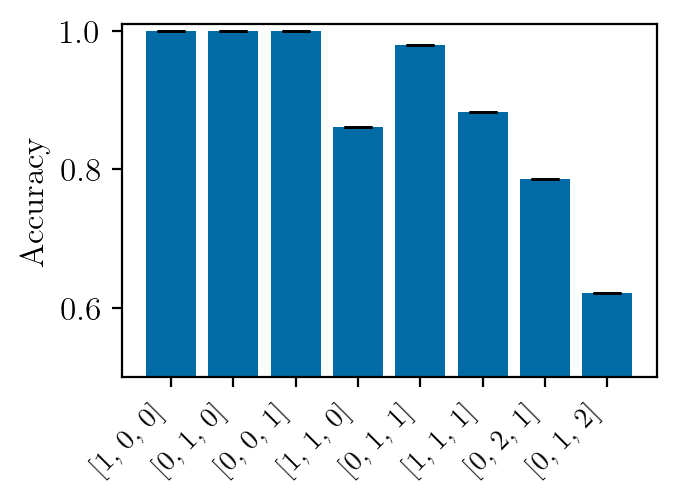

In [7]:
# Number of classes
num_classes = 8

# Initialize an array to store accuracies for each class across folds
class_accuracies_folds = np.zeros((len(kfold_models), num_classes))

# Calculate per-class accuracy for each fold
for fold_idx, model in enumerate(kfold_models):
    fold_accuracies = []
    for cls in range(num_classes):
        # Mask for the current class
        
        class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
        # Calculate accuracy for the current fold and class
        # /np.sum(np.ones_like(y_test[:,0]))
        class_accuracy = np.sum(np.sum(np.round(_pred[class_mask])==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
        fold_accuracies.append(class_accuracy)
    class_accuracies_folds[fold_idx] = fold_accuracies

# Compute mean and standard deviation of accuracies across folds
class_accuracies_mean = class_accuracies_folds.mean(axis=0)
class_accuracies_std = class_accuracies_folds.std(axis=0)

# Bar plot with error bars
fig, ax = plt.subplots(figsize=(3.54331, 3.54331*0.75))
ax.bar(range(num_classes), class_accuracies_mean, yerr=class_accuracies_std,  capsize=5)
ax.set_ylabel('Accuracy')

ax.set_xticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)

ax.set_ylim(0.5, 1.01)  # Accuracy goes from 0 to 1
plt.tight_layout()
plt.show()

